## PCA and UMAP on the Fundamentals - Sectors 

<p> Date: 2026-11-11 &emsp;&emsp;&emsp; 
<br><br> 

**Source Data**: [New York Stock Exchange](https://www.kaggle.com/datasets/dgawlik/nyse?select=securities.csv)

**Content:** <br>
- [Raw Data: prices-split-adjusted.csv](#raw-data-price-adjusted)

- [Raw Data: Fundamentals.csv](#fundamentalscsv)

- [PCA: Fundamentals](#principal-component-analysis)

- [UMAP: Fundamentals](#umpa)

### Summary

1. Total ticker 501, with 470 (93%) tickers with 1500 record and 448 (89.4%). There are about 10% data loss, That loss of the 10% will be added back when applying the 80:20 rules, which means that instead of using 20%, we will use top **22.5%** from the sectors.  

2. 

### Raw data: Price-Adjusted

In [1]:
## >> 1.1 System Setup and Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df = pd.read_csv("../data/raw/prices-split-adjusted.csv", parse_dates=["date"])
df['symbol'].value_counts()

symbol
KSU     1762
NOC     1762
ORCL    1762
OMC     1762
OKE     1762
        ... 
KHC      378
HPE      304
CSRA     284
WLTW     251
FTV      126
Name: count, Length: 501, dtype: int64

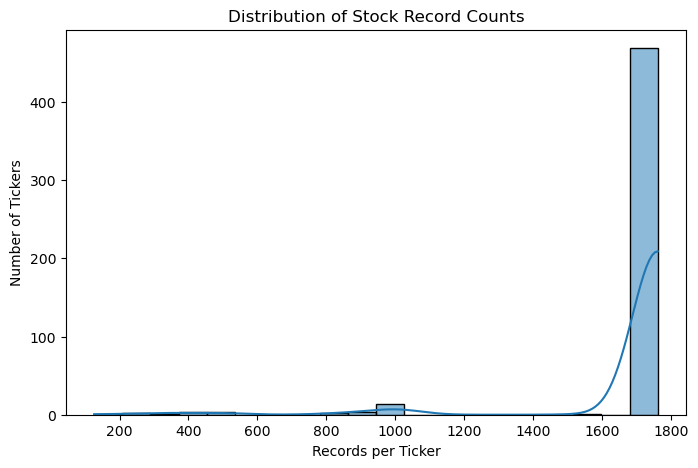

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Count records per ticker
ticker_counts = df['symbol'].value_counts()
# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(ticker_counts, bins=20, kde=True)
plt.title("Distribution of Stock Record Counts")
plt.xlabel("Records per Ticker")
plt.ylabel("Number of Tickers")
plt.show()


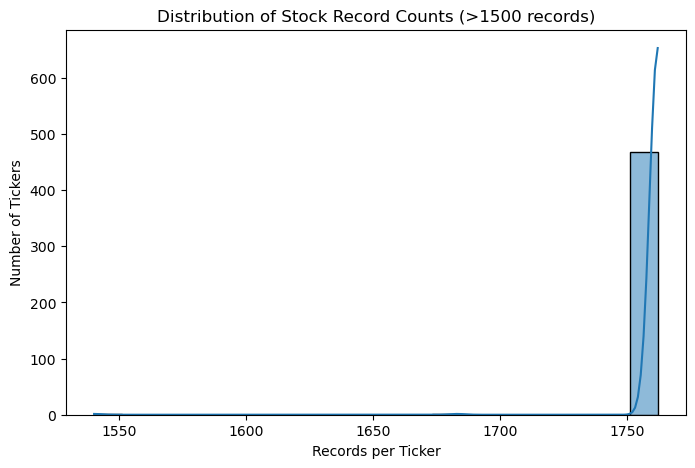

In [4]:
## >> Filter_counts > 1500
# Count records per ticker
ticker_counts = df['symbol'].value_counts()
# Filter tickers with more than 1500 records
filtered_counts = ticker_counts[ticker_counts > 1500]
# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(filtered_counts, bins=20, kde=True)
plt.title("Distribution of Stock Record Counts (>1500 records)")
plt.xlabel("Records per Ticker")
plt.ylabel("Number of Tickers")
plt.show()

In [5]:
df_filtered = df.groupby('symbol').filter(lambda x: len(x) > 1500) # make all the data is in the same length

print(f"Total Ticker :{len(df['symbol'].value_counts())}")
print(f"Ticker with > 1500 records :{len(df_filtered['symbol'].value_counts())}")
df_filtered


Total Ticker :501
Ticker with > 1500 records :470


,date,symbol,open,close,low,high,volume
251,2010-01-04,A,22.453504,22.389128,22.267525,22.625180,3815500.0
252,2010-01-04,AAL,4.840000,4.770000,4.660000,4.940000,9837300.0
253,2010-01-04,AAP,40.700001,40.380001,40.360001,41.040001,1701700.0
254,2010-01-04,AAPL,30.490000,30.572857,30.340000,30.642857,123432400.0
255,2010-01-04,ABC,26.290001,26.629999,26.139999,26.690001,2455900.0
...,...,...,...,...,...,...,...
851257,2016-12-30,YHOO,38.720001,38.669998,38.430000,39.000000,6431600.0
851258,2016-12-30,YUM,63.930000,63.330002,63.160000,63.939999,1887100.0
851259,2016-12-30,ZBH,103.309998,103.199997,102.849998,103.930000,973800.0
851260,2016-12-30,ZION,43.070000,43.040001,42.689999,43.310001,1938100.0


In [6]:
### >>  map price data to the GICs sectors 

df_security = pd.read_csv("../data/raw/securities.csv")
# creates a dictionary that maps ticker to its GICS sector
tick_to_sec = dict(zip(df_security['Ticker symbol'], df_security['GICS Sector'])) 

# map the ticker to the price data 
df_price = df_filtered.copy()
df_price['Sector'] = df_price['symbol'].map(tick_to_sec)
display(df_price)

## >> check for NA nad INF before removing it
# check if df has any NA

has_nan = df_price.isna().any().any()
print(f"Contain NA: {has_nan}")  # False

# check if has any INF
numeric_cols = df_price.select_dtypes(include=[np.number])
has_inf = numeric_cols.isin([np.inf, -np.inf]).any().any()
print(f"Contain INF: {has_inf}")  # True


,date,symbol,open,close,low,high,volume,Sector
251,2010-01-04,A,22.453504,22.389128,22.267525,22.625180,3815500.0,Health Care
252,2010-01-04,AAL,4.840000,4.770000,4.660000,4.940000,9837300.0,Industrials
253,2010-01-04,AAP,40.700001,40.380001,40.360001,41.040001,1701700.0,Consumer Discretionary
254,2010-01-04,AAPL,30.490000,30.572857,30.340000,30.642857,123432400.0,Information Technology
255,2010-01-04,ABC,26.290001,26.629999,26.139999,26.690001,2455900.0,Health Care
...,...,...,...,...,...,...,...,...
851257,2016-12-30,YHOO,38.720001,38.669998,38.430000,39.000000,6431600.0,Information Technology
851258,2016-12-30,YUM,63.930000,63.330002,63.160000,63.939999,1887100.0,Consumer Discretionary
851259,2016-12-30,ZBH,103.309998,103.199997,102.849998,103.930000,973800.0,Health Care
851260,2016-12-30,ZION,43.070000,43.040001,42.689999,43.310001,1938100.0,Financials


Contain NA: False
Contain INF: False


### Fundamentals.csv

In [7]:
## load fundamentals 
df_fundamentals = pd.read_csv("../data/raw/fundamentals.csv")

## >> only use ticker from df_price

# Get tickers from df_price (470 tickers)
valid_tickers = set(df_price['symbol'].unique())

# Get tickers from df_fundamentals (original set)
original_tickers = set(df_fundamentals['Ticker Symbol'].unique())

# Find which tickers to remove
tickers_to_remove = original_tickers - valid_tickers
print(f"Removing {len(tickers_to_remove)} tickers: {tickers_to_remove}")

# Filter df_fundamentals
df_fundamentals_ = df_fundamentals[df_fundamentals['Ticker Symbol'].isin(valid_tickers)]
df_fundamentals_sector = df_fundamentals.copy()
df_fundamentals_sector['Sector'] = df_fundamentals_sector["Ticker Symbol"].map(tick_to_sec)
df_fundamentals_sector


Removing 28 tickers: {'FBHS', 'CSRA', 'COTY', 'NWS', 'XYL', 'ALLE', 'SYF', 'WLTW', 'TDG', 'QRVO', 'KMI', 'WRK', 'TRIP', 'KORS', 'HPE', 'NLSN', 'PSX', 'DLPH', 'NAVI', 'CFG', 'ZTS', 'NWSA', 'ABBV', 'MPC', 'UA', 'FB', 'PYPL', 'HCA'}


,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,Sector
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08,Industrials
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08,Industrials
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08,Industrials
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08,Industrials
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07,Consumer Discretionary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,1776,ZION,2015-12-31,0.000000e+00,0.0,-2.530000e+06,4.0,-1.573610e+08,0.000000e+00,NaN,...,0.000000e+00,7.507519e+09,5.216201e+10,5.966952e+10,2.210591e+09,0.0,2015.0,1.20,2.578925e+08,Financials
1777,1777,ZTS,2013-12-31,1.381000e+09,-99000000.0,9.000000e+06,54.0,-1.840000e+08,8.780000e+08,43.0,...,1.415000e+09,9.400000e+08,5.618000e+09,6.558000e+09,4.561000e+09,0.0,2013.0,1.01,4.990099e+08,Health Care
1778,1778,ZTS,2014-12-31,1.071000e+09,69000000.0,-7.000000e+06,44.0,-1.800000e+08,9.580000e+08,81.0,...,1.086000e+09,1.311000e+09,5.277000e+09,6.588000e+09,4.785000e+09,0.0,2014.0,1.16,5.025862e+08,Health Care
1779,1779,ZTS,2015-12-31,1.313000e+09,-58000000.0,-8.100000e+07,32.0,-2.240000e+08,1.012000e+09,65.0,...,1.781000e+09,1.068000e+09,6.845000e+09,7.913000e+09,4.765000e+09,-203000000.0,2015.0,0.68,4.985294e+08,Health Care


In [8]:
print(f"Total Ticker :{len(df['symbol'].value_counts())}")
print(f"Ticker with > 1500 records :{len(df_filtered['symbol'].value_counts())}")
print(f"Total number of Tikcer in funadmentals with >1500 records: {len(df_fundamentals_sector['Ticker Symbol'].unique())}")



Total Ticker :501
Ticker with > 1500 records :470
Total number of Tikcer in funadmentals with >1500 records: 448


In [9]:
print(df_fundamentals_sector.columns)
len(df_fundamentals_sector.columns)

Index(['Unnamed: 0', 'Ticker Symbol', 'Period Ending', 'Accounts Payable',
       'Accounts Receivable', 'Add'l income/expense items', 'After Tax ROE',
       'Capital Expenditures', 'Capital Surplus', 'Cash Ratio',
       'Cash and Cash Equivalents', 'Changes in Inventories', 'Common Stocks',
       'Cost of Revenue', 'Current Ratio', 'Deferred Asset Charges',
       'Deferred Liability Charges', 'Depreciation',
       'Earnings Before Interest and Tax', 'Earnings Before Tax',
       'Effect of Exchange Rate',
       'Equity Earnings/Loss Unconsolidated Subsidiary', 'Fixed Assets',
       'Goodwill', 'Gross Margin', 'Gross Profit', 'Income Tax',
       'Intangible Assets', 'Interest Expense', 'Inventory', 'Investments',
       'Liabilities', 'Long-Term Debt', 'Long-Term Investments',
       'Minority Interest', 'Misc. Stocks', 'Net Borrowings', 'Net Cash Flow',
       'Net Cash Flow-Operating', 'Net Cash Flows-Financing',
       'Net Cash Flows-Investing', 'Net Income', 'Net Income Ad

80

In [10]:
df_fundamentals_sector["Sector"].value_counts()

Sector
Consumer Discretionary         316
Industrials                    248
Information Technology         237
Financials                     211
Health Care                    194
Consumer Staples               132
Energy                         124
Real Estate                    108
Utilities                       96
Materials                       95
Telecommunications Services     20
Name: count, dtype: int64

In [11]:
df_price

,date,symbol,open,close,low,high,volume,Sector
251,2010-01-04,A,22.453504,22.389128,22.267525,22.625180,3815500.0,Health Care
252,2010-01-04,AAL,4.840000,4.770000,4.660000,4.940000,9837300.0,Industrials
253,2010-01-04,AAP,40.700001,40.380001,40.360001,41.040001,1701700.0,Consumer Discretionary
254,2010-01-04,AAPL,30.490000,30.572857,30.340000,30.642857,123432400.0,Information Technology
255,2010-01-04,ABC,26.290001,26.629999,26.139999,26.690001,2455900.0,Health Care
...,...,...,...,...,...,...,...,...
851257,2016-12-30,YHOO,38.720001,38.669998,38.430000,39.000000,6431600.0,Information Technology
851258,2016-12-30,YUM,63.930000,63.330002,63.160000,63.939999,1887100.0,Consumer Discretionary
851259,2016-12-30,ZBH,103.309998,103.199997,102.849998,103.930000,973800.0,Health Care
851260,2016-12-30,ZION,43.070000,43.040001,42.689999,43.310001,1938100.0,Financials


### Principal Component Analysis

In [12]:
##### >>> 3. PCA analysis on fundamentals 

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

### >> 3.1 Data Preprocessing & PCA Implementation

# Select only numeric columns (exclude identifiers)
exclude_cols = ['Unnamed: 0', 'Ticker Symbol', 'Period Ending', 'For Year', 'Sector']
numeric_cols = df_fundamentals_sector.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

# Handle missing values
df_clean = df_fundamentals_sector[numeric_cols].copy()
df_clean = df_clean.fillna(df_clean.median())  # or use mean()

# Remove infinite values
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.fillna(df_clean.median())

# Standardize the features (crucial for PCA!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

print(f"Shape of scaled data: {df_scaled.shape}")

Shape of scaled data: (1781, 75)


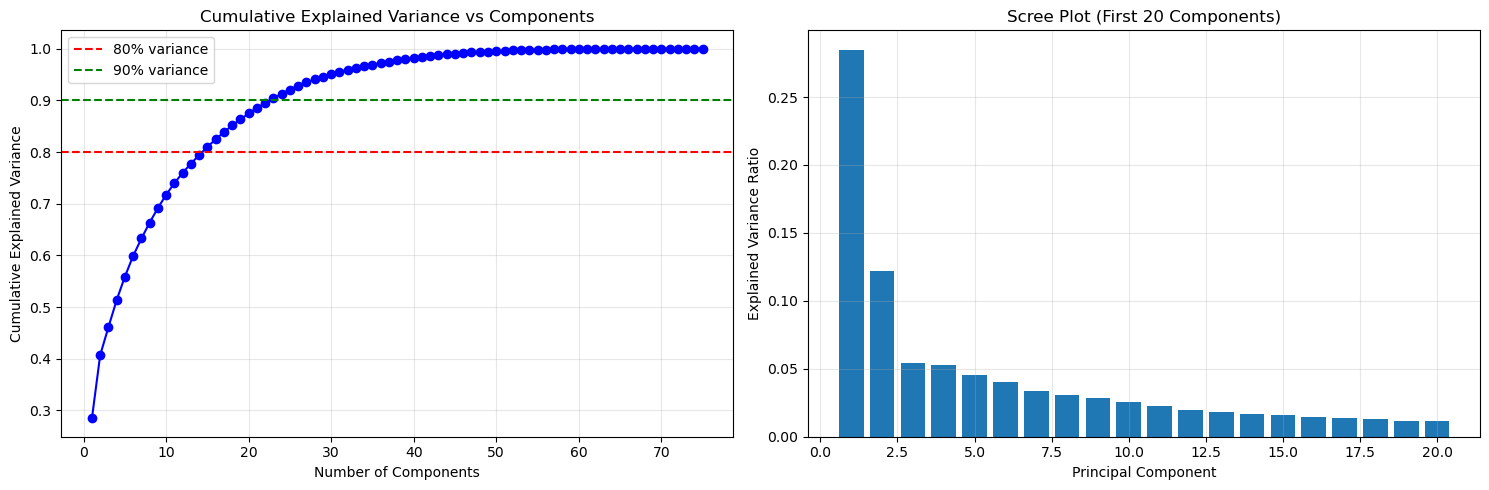

Components for 80% variance: 15
Components for 90% variance: 23


In [13]:
## >> 3.2 Perform PCA with all components
pca_full = PCA()
pca_full.fit(df_scaled)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cumulative explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[0].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-')
axes[0].axhline(y=0.80, color='r', linestyle='--', label='80% variance')
axes[0].axhline(y=0.90, color='g', linestyle='--', label='90% variance')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Cumulative Explained Variance vs Components')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Individual explained variance (scree plot)
axes[1].bar(range(1, 21), pca_full.explained_variance_ratio_[:20])
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Scree Plot (First 20 Components)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for 80% and 90% variance
n_components_80 = np.argmax(cumsum_var >= 0.80) + 1
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1

print(f"Components for 80% variance: {n_components_80}")
print(f"Components for 90% variance: {n_components_90}")


In [14]:
## [Option] Interactive scree plot
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# pca = pca_full

variance_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Variance Explained': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

fig = make_subplots(rows=1, cols=2, subplot_titles=('Individual Variance Explained', 'Cumulative Variance Explained'))

# Bar chart
fig.add_trace(
    go.Bar(x=variance_df['Component'][:20],  # First 20
           y=variance_df['Variance Explained'][:20],
           marker_color='steelblue',
           hovertemplate='%{x}<br>Variance: %{y:.4f}<extra></extra>'),
           row=1, col=1
           )

# Line chart
fig.add_trace(
    go.Scatter(x=variance_df['Component'][:20],
               y=variance_df['Cumulative Variance'][:20],
               mode='lines+markers',
               marker=dict(size=8, color='darkred'),
               line=dict(width=2, color='darkred'),
               hovertemplate='%{x}<br>Cumulative: %{y:.4f}<extra></extra>'),
               row=1, col=2
               )

# Add 80% and 90% reference lines
fig.add_hline(y=0.8, line_dash="dash", line_color="green", 
              annotation_text="80%", row=1, col=2)
fig.add_hline(y=0.9, line_dash="dash", line_color="orange", 
              annotation_text="90%", row=1, col=2)

fig.update_xaxes(title_text="Principal Component", row=1, col=1)
fig.update_xaxes(title_text="Principal Component", row=1, col=2)
fig.update_yaxes(title_text="Variance Explained", row=1, col=1)
fig.update_yaxes(title_text="Cumulative Variance", row=1, col=2)

fig.update_layout(
    height=500,
    width=1200,
    title_text="PCA Variance Analysis",
    showlegend=False,
    plot_bgcolor='rgba(240,240,240,0.5)'
)
fig.update_xaxes(tickfont=dict(size=16))
fig.update_yaxes(tickfont=dict(size=16))

fig.show()

NameError: name 'pca' is not defined

In [ ]:
## 3. Use PCA with chosen number of components (e.g., for 80% variance)

n_components = n_components_80  # Adjust as needed
pca = PCA(n_components=n_components)
df_pca = pca.fit_transform(df_scaled)

# Create PCA dataframe
pca_cols = [f'PC{i+1}' for i in range(n_components)]
df_pca_full = pd.DataFrame(df_pca, columns=pca_cols, index=df_fundamentals.index)

# Add back sector and ticker information
df_pca_full['Sector'] = df_fundamentals_sector['Sector'].values
df_pca_full['Ticker'] = df_fundamentals_sector['Ticker Symbol'].values

print(f"PCA shape: {df_pca_full.shape}")
print(f"\nExplained variance by component:")
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")


In [ ]:
##### =========== Plot =========== ##### 
### >>> 4. Visualize PCA Results <<< ### 

r_palette = [  # 11 colors
    '#8B1A1A',  # firebrick4
    '#FF6347',  # tomato
    '#CD8500',  # darkorange3
    '#458B00',  # chartreuse4
    '#006400',  # darkgreen
    '#4682b4',  # Steelblue
    '#1874CD',  # dodgerblue3
    '#B452CD',  # mediumpurple1
    '#9932CC',  # darkorchid2
    '#8B008B',  # darkmagenta
    '#8B5A2B'   # tan4
]


In [ ]:
### >> Plot 1: 2D PCA visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by sector
sectors = df_pca_full['Sector'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(sectors)))

for sector, color in zip(sectors, colors):
    mask = df_pca_full['Sector'] == sector
    axes[0].scatter(df_pca_full.loc[mask, 'PC1'], 
                   df_pca_full.loc[mask, 'PC2'],
                   label=sector, alpha=0.6, s=50, color=color)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0].set_title('PCA: First Two Components by Sector')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

# PC2 vs PC3
for sector, color in zip(sectors, colors):
    mask = df_pca_full['Sector'] == sector
    axes[1].scatter(df_pca_full.loc[mask, 'PC2'], 
                   df_pca_full.loc[mask, 'PC3'],
                   label=sector, alpha=0.6, s=50, color=color)

axes[1].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)')
axes[1].set_title('PCA: PC2 vs PC3 by Sector')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
### >> Plot2: Interactive 2D PCA with R Palette

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Prepare data
X = 'PC1'  # <-- can be changed from PC1 to PC10 
Y = 'PC2'  # <-- can be changed from PC1 to PC10 

df_pca_plot = df_pca_full.copy()
if 'Total Revenue' in df_fundamentals.columns:
    df_pca_plot['Revenue'] = df_fundamentals['Total Revenue'].values
if 'Total Assets' in df_fundamentals.columns:
    df_pca_plot['Assets'] = df_fundamentals['Total Assets'].values
if 'Net Income' in df_fundamentals.columns:
    df_pca_plot['Net Income'] = df_fundamentals['Net Income'].values

# Create sector to color mapping
sectors = sorted(df_pca_plot['Sector'].unique())
sector_colors = {sector: r_palette[i % len(r_palette)] 
                 for i, sector in enumerate(sectors)}

# Single plot version
fig = go.Figure()

for sector in sectors:
    sector_data = df_pca_plot[df_pca_plot['Sector'] == sector]
    
    # Prepare hover text
    hover_text = []
    for idx, row in sector_data.iterrows():
        text = f"<b>{row['Ticker']}</b><br>"
        text += f"Sector: {sector}<br>"
        text += f"{X}: {row[X]:.2f}<br>"
        text += f"{Y}: {row[Y]:.2f}<br>"
        if 'Revenue' in sector_data.columns:
            text += f"Revenue: ${row['Revenue']:,.0f}<br>"
        if 'Assets' in sector_data.columns:
            text += f"Assets: ${row['Assets']:,.0f}<br>"
        if 'Net Income' in sector_data.columns:
            text += f"Net Income: ${row['Net Income']:,.0f}"
        hover_text.append(text)
    
    fig.add_trace(
        go.Scatter(x=sector_data[X],y=sector_data[Y],
                   mode='markers',name=sector,
                   marker=dict(size=15,
                               color=sector_colors[sector],
                               opacity=0.75,
                               line=dict(width=1, color='white')),
                            text=hover_text,
                            hovertemplate='%{text}<extra></extra>'
                              ))

fig.update_layout(
    width=1300,height=1000,
    title=dict(
        text=f'PCA Visualization: {X} vs {Y}<br>({(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.2f}% variance explained)',
        font=dict(size=18)
    ),
    xaxis=dict(
        title=f'{X} ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        title_font=dict(size=18),  # Increase x-axis title font size
        gridcolor='lightgray',
        showgrid=True,
        zeroline=True,
        zerolinecolor='gray',
        zerolinewidth=2
    ),
    yaxis=dict(
        title=f'{Y} ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        title_font=dict(size=18),  # Increase y-axis title font size
        gridcolor='lightgray',
        showgrid=True,
        zeroline=True,
        zerolinecolor='gray',
        zerolinewidth=2
    ),
    hovermode='closest',
    plot_bgcolor='white',
    legend=dict(
        title=dict(text='<b>GICS Sector</b>', font=dict(size=16)),
        bgcolor="rgba(255,255,255,0.95)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=16),
        itemsizing='constant'
    )
)
fig.update_xaxes(tickfont=dict(size=16))
fig.update_yaxes(tickfont=dict(size=16))
fig.show()

# # Optional — export to HTML for sharing
# fig.write_html(f"../html/{Tick}_LSTM_Pred_vs_Actual_history.html")
# print(f"✅ Plotly chart saved as '{Tick}_LSTM_Pred_vs_Actual.html'")
# webbrowser.open(f"../html/{Tick}_LSTM_Pred_vs_Actual_history.html")

In [ ]:
###>> Plot3: Interactive 2D PCA with 2 subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        f'PC1 vs PC2 ({(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.2f}% var)',
        f'PC2 vs PC3 ({(pca.explained_variance_ratio_[1] + pca.explained_variance_ratio_[2])*100:.2f}% var)'
    )
)

# Create sector to color mapping
sectors = sorted(df_pca_plot['Sector'].unique())
sector_colors = {sector: r_palette[i % len(r_palette)] 
                 for i, sector in enumerate(sectors)}

# PC1 vs PC2
for sector in sectors:
    sector_data = df_pca_plot[df_pca_plot['Sector'] == sector]
    
    fig.add_trace(
        go.Scatter(x=sector_data['PC1'],y=sector_data['PC2'],
                   mode='markers',name=sector,
                   marker=dict(size=12,
                               color=sector_colors[sector],
                               opacity=0.75,
                               line=dict(width=0.8, color='white')),
                               text=sector_data['Ticker'],
                               hovertemplate='<b>%{text}</b><br>' +
                               '{sector}<br>' +
                               'PC1: %{x:.2f}<br>' +
                               'PC2: %{y:.2f}<br>' +
                            '<extra></extra>',
                            legendgroup=sector,
                            showlegend=True
                            ),
                          row=1, col=1
                          )

# PC2 vs PC3
for sector in sectors:
    sector_data = df_pca_plot[df_pca_plot['Sector'] == sector]
    
    fig.add_trace(
        go.Scatter(x=sector_data['PC2'],y=sector_data['PC3'],
                   mode='markers',name=sector,
                   marker=dict(size=12,
                               color=sector_colors[sector],
                               opacity=0.75,
                               line=dict(width=0.8, color='white')),
                               text=sector_data['Ticker'],
                               hovertemplate='<b>%{text}</b><br>' +
                               f'{sector}<br>' +
                               'PC2: %{x:.2f}<br>' +
                               'PC3: %{y:.2f}<br>' +
                            '<extra></extra>',
                            legendgroup=sector,
                            showlegend=False
                            ),
                        row=1, col=2
                        )

# Update axes
fig.update_xaxes(
    title_text=f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
    title_font=dict(size=15),  
    gridcolor='lightgray',
    showgrid=True,
    zeroline=True,
    zerolinecolor='gray',
    zerolinewidth=1.5,
    row=1, col=1
)
fig.update_yaxes(
    title_text=f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
    title_font=dict(size=15),  
    gridcolor='lightgray',
    showgrid=True,
    zeroline=True,
    zerolinecolor='gray',
    zerolinewidth=1.5,
    row=1, col=1
)
fig.update_xaxes(
    title_text=f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
    title_font=dict(size=15),  
    gridcolor='lightgray',
    showgrid=True,
    zeroline=True,
    zerolinecolor='gray',
    zerolinewidth=1.5,
    row=1, col=2
)
fig.update_yaxes(
    title_text=f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)',
    title_font=dict(size=15),  
    gridcolor='lightgray',
    showgrid=True,
    zeroline=True,
    zerolinecolor='gray',
    zerolinewidth=1.5,
    row=1, col=2
)

fig.update_layout(
    height=650,
    width=1500,
    title_text="<b>PCA Analysis by GICS Sector</b>",
    title_font_size=18,
    hovermode='closest',
    plot_bgcolor='white',
    legend=dict(
        title=dict(text='<b>Sector</b>', font=dict(size=16)),
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.01,
        bgcolor="rgba(255,255,255,0.95)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=10)
    )
)
fig.update_xaxes(tickfont=dict(size=16))
fig.update_yaxes(tickfont=dict(size=16))
fig.show()

In [ ]:
### >> Plot 4: Interactive feceted plot

# Create faceted plot - one subplot per sector
# Create sector to color mapping
sectors = sorted(df_pca_plot['Sector'].unique())
sector_colors = {sector: r_palette[i % len(r_palette)] 
                 for i, sector in enumerate(sectors)}


fig = px.scatter(df_pca_plot, x='PC1', y='PC2',
                 color='Sector', facet_col='Sector', facet_col_wrap=3,  # 3 columns
                 hover_name='Ticker',
                 hover_data={'PC1': ':.2f',
                             'PC2': ':.2f',
                             'Sector': False,  # Don't show in hover since it's the title
                             'Revenue': ':,.0f' if 'Revenue' in df_pca_plot.columns else False,
                             'Assets': ':,.0f' if 'Assets' in df_pca_plot.columns else False,
                             'Net Income': ':,.0f' if 'Net Income' in df_pca_plot.columns else False
                             },
    title='PCA by Sector - Faceted View',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)'
    },
    color_discrete_map=sector_colors
)

# Update marker style
fig.update_traces(marker=dict(size=15,opacity=0.75,line=dict(width=1, color='white')))


# Update layout
fig.update_layout(height=100,width=1500,showlegend=False,title_font_size=18,plot_bgcolor='white',font=dict(size=16))

# Update all subplot axes
fig.update_xaxes(showgrid=True,gridcolor='lightgray',zeroline=True,zerolinecolor='gray',zerolinewidth=1)
fig.update_yaxes(showgrid=True,gridcolor='lightgray',zeroline=True,zerolinecolor='gray',zerolinewidth=1,
                 tickvals=[-20,-10,0,10,20,30], # Set specific tick values
                    tickmode='array'   
                 ) 

fig.update_layout(height=1800, width=1400, showlegend=False)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

In [ ]:
### >> PCA MASTER DIAGNOSTIC SCRIPT
def diagnose_pca_plot(df_pca_plot, fig):
    """Complete diagnostic of PCA plotting"""
    
    print("\n" + "="*70)
    print("COMPLETE PCA PLOT DIAGNOSTIC")
    print("="*70)
    
    # Basic counts
    n_data = len(df_pca_plot)
    n_plotted = sum(len(trace.x) for trace in fig.data if hasattr(trace, 'x') and trace.x is not None)
    
    print(f"\n📊 SUMMARY:")
    print(f"   Points in dataframe: {n_data}")
    print(f"   Points in plot: {n_plotted}")
    print(f"   Difference: {n_data - n_plotted}")
    
    if n_data == n_plotted:
        print(f"\n   ✅ SUCCESS: All points are plotted!")
    else:
        print(f"\n   ⚠️ ISSUE: {n_data - n_plotted} points missing from plot")
    
    # Check for overlapping
    unique_positions = df_pca_plot[['PC1', 'PC2']].round(1).drop_duplicates()
    print(f"\n📍 OVERLAPPING:")
    print(f"   Unique positions: {len(unique_positions)}")
    print(f"   Total points: {n_data}")
    if len(unique_positions) < n_data * 0.9:
        print(f"   ⚠️ LIKELY: Many points overlap (you see ~{len(unique_positions)} visually)")
    
    print("="*70 + "\n")
    
    return n_data, n_plotted

# Run it
diagnose_pca_plot(df_pca_plot, fig)


In [ ]:
### >> 5. Feature Importance (Loading Scores)

## Get feature importance for each component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=numeric_cols
)

# Top features for PC1 and PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# PC1 top features
pc1_importance = loadings['PC1'].abs().sort_values(ascending=False).head(15)
pc1_importance.plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 15 Features Contributing to PC1')
axes[0].set_xlabel('Absolute Loading')

# PC2 top features
pc2_importance = loadings['PC2'].abs().sort_values(ascending=False).head(15)
pc2_importance.plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 15 Features Contributing to PC2')
axes[1].set_xlabel('Absolute Loading')

plt.tight_layout()
plt.show()

# Print top contributors
print("\nTop 10 features for PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10))


print("\nTop 10 features for PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(10))

### UMAP: Uniform Manifold Approximation and Projection

#### Background
UMAP is a dimensionality-reduction method, which takes high-dimensional data and project it into 2D or 3D while keeping its structure as intact as possible. 
- Concept: it assumes your data lies on some curved “manifold” in high-dimensional space, then tries to map it into a lower-dimensional space without losing too much of the important shape.


#### UMAP vs PCA vs t-SNE

| Feature / Property                | **UMAP**                                 | **PCA**                                        | **t-SNE**                       |
| --------------------------------- | ---------------------------------------- | ---------------------------------------------- | ------------------------------- |
| **Type**                          | Nonlinear manifold learning              | Linear projection                              | Nonlinear manifold learning     |
| **Captures nonlinear structure?** | ✔ Excellent                              | ✘ No                                           | ✔ Very good                     |
| **Preserves local structure?**    | ✔ Strong                                 | ▲ Moderate                                     | ✔ Very strong                   |
| **Preserves global structure?**   | ✔ Better than t-SNE                      | ▲ Moderate                                     | ✘ Weak                          |
| **Scalability**                   | ✔ Fast on large datasets                 | ✔ Very fast                                    | ✘ Slow on large datasets        |
| **Distance metrics**              | ✔ Many (Euclidean, cosine, correlation…) | Mostly Euclidean                               | Mostly Euclidean                |
| **Output stability**              | ▲ Reasonably stable                      | ✔ Highly stable                                | ✘ Often variable between runs   |
| **Ideal output dimension**        | 2–50                                     | Any                                            | Best for 2–3                    |
| **Typical use**                   | Visualization, clustering, embeddings    | Preprocessing, linear dimensionality reduction | Visualization of dense clusters |
| **Parameter sensitivity**         | ▲ Medium                                 | ✔ Low                                          | ✘ High                          |
| **Computational cost**            | Medium                                   | Low                                            | High                            |
| **Cluster separation**            | ✔ Good                                   | ▲ Weak                                         | ✔ Very good, but exaggerated    |



#### Summary
- UMAP is the “balanced” choice: good global + local structure, fast, flexible distance metrics.
- PCA is best for linear relationships, preprocessing, or when you need speed and interpretability.
- t-SNE is best when you need super-tight cluster visualization and don’t care about global relationships.

In [ ]:
##### >>> 4. UMAP + PCA

### >>> 4.1 UMAP + PCA-Reduced (n=20)
import umap
# import plotly.express as px
# import plotly.graph_objects as go

## Use PCA to reduce to ~20 components, then UMAP to 2D
pca_pre = PCA(n_components=20)
df_pca_pre = pca_pre.fit_transform(df_scaled)

print(f"PCA pre-processing: {df_pca_pre.shape}")

# Apply UMAP on PCA-reduced data
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(df_pca_pre)

print(f"UMAP embedding: {embedding.shape}")

# Create UMAP dataframe
df_umap = pd.DataFrame(
    embedding,
    columns=['UMAP1', 'UMAP2'],
    index=df_fundamentals.index
)

# Add sector and ticker information
df_umap['Sector'] = df_fundamentals_sector['Sector'].values
df_umap['Ticker'] = df_fundamentals_sector['Ticker Symbol'].values

# Add financial data for hover
if 'Total Revenue' in df_fundamentals.columns:
    df_umap['Revenue'] = df_fundamentals['Total Revenue'].values
if 'Total Assets' in df_fundamentals.columns:
    df_umap['Assets'] = df_fundamentals['Total Assets'].values
if 'Net Income' in df_fundamentals.columns:
    df_umap['Net Income'] = df_fundamentals['Net Income'].values

print(f"\nUMAP dataframe shape: {df_umap.shape}")
print(f"Sectors: {df_umap['Sector'].nunique()}")
print(f"Companies: {len(df_umap)}")

In [ ]:
## >> Plot 5: Simple UMAP matplot

# Use PCA to reduce to ~20 components, then UMAP to 2D
pca_pre = PCA(n_components=20)
df_pca_pre = pca_pre.fit_transform(df_scaled)

# Apply UMAP on PCA-reduced data
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(df_pca_pre)

# Visualize
plt.figure(figsize=(12, 8))
for sector, color in zip(sectors, colors):
    mask = df_fundamentals_sector['Sector'] == sector
    plt.scatter(embedding[mask, 0], embedding[mask, 1], 
                label=sector, alpha=0.6, s=50, color=color)

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP on PCA-Reduced Data (20 components)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### >> Plot 6: Interactive UMAP matplot

# Create interactive UMAP scatter plot with Reduced-PCA
fig = go.Figure()
sectors = sorted(df_umap['Sector'].unique())

for sector in sectors:
    sector_data = df_umap[df_umap['Sector'] == sector]
    
    # Prepare hover text
    hover_text = []
    for idx, row in sector_data.iterrows():
        text = f"<b>{row['Ticker']}</b><br>"
        text += f"Sector: {sector}<br>"
        text += f"UMAP1: {row['UMAP1']:.2f}<br>"
        text += f"UMAP2: {row['UMAP2']:.2f}<br>"
        if 'Revenue' in sector_data.columns:
            text += f"Revenue: ${row['Revenue']:,.0f}<br>"
        if 'Assets' in sector_data.columns:
            text += f"Assets: ${row['Assets']:,.0f}<br>"
        if 'Net Income' in sector_data.columns:
            text += f"Net Income: ${row['Net Income']:,.0f}"
        hover_text.append(text)
    
    fig.add_trace(go.Scatter(
        x=sector_data['UMAP1'],
        y=sector_data['UMAP2'],
        mode='markers',
        name=sector,
        marker=dict(
            size=15,
            color=sector_colors[sector],
            opacity=0.75,
            line=dict(width=1, color='white')
        ),
        text=hover_text,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_layout(
    width=1300,
    height=800,
    title=dict(
        text='<b>UMAP Visualization on PCA-Reduced Data</b><br>20 PCA components → 2D UMAP projection',
        font=dict(size=18)
    ),
    xaxis=dict(
        title='UMAP Dimension 1',
        title_font=dict(size=15),  
        gridcolor='lightgray',
        showgrid=True,
        zeroline=True,
        zerolinecolor='gray',
        zerolinewidth=2
    ),
    yaxis=dict(
        title='UMAP Dimension 2',
        title_font=dict(size=15),  
        gridcolor='lightgray',
        showgrid=True,
        zeroline=True,
        zerolinecolor='gray',
        zerolinewidth=2
    ),
    hovermode='closest',
    plot_bgcolor='white',
    legend=dict(
        title=dict(text='<b>GICS Sector</b>', font=dict(size=15)),
        bgcolor="rgba(255,255,255,0.95)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=16),
        itemsizing='constant'
    )
)

fig.update_xaxes(tickfont=dict(size=16))
fig.update_yaxes(tickfont=dict(size=16))
fig.show()

In [ ]:
### >> [Option] Plot 6: Interactive UMAP matplot

# Create interactive UMAP scatter plot with Reduced-PCA

# Faceted UMAP plot
n_sectors = len(sectors)
n_cols = 3
n_rows = int(np.ceil(n_sectors / n_cols))

fig = px.scatter(
    df_umap,
    x='UMAP1',
    y='UMAP2',
    color='Sector',
    facet_col='Sector',
    facet_col_wrap=3,
    hover_name='Ticker',
    hover_data={
        'UMAP1': ':.2f',
        'UMAP2': ':.2f',
        'Sector': False,
        'Revenue': ':,.0f' if 'Revenue' in df_umap.columns else False,
        'Assets': ':,.0f' if 'Assets' in df_umap.columns else False,
    },
    title=f'<b>UMAP by GICS Sector - Faceted View</b><br>{n_sectors} sectors, {len(df_umap)} companies',
    labels={
        'UMAP1': 'UMAP 1',
        'UMAP2': 'UMAP 2'
    },
    color_discrete_map=sector_colors
)

fig.update_traces(
    marker=dict(
        size=12,
        opacity=0.8,
        line=dict(width=1, color='white')
    )
)

fig.update_layout(
    height=400 * n_rows,
    width=1600,
    showlegend=False,
    plot_bgcolor='white',
    font=dict(size=15),
    margin=dict(t=150)  # Increase top margin (default is ~100)
)

# Clean up facet titles
fig.for_each_annotation(lambda a: a.update(
    text=f"<b>{a.text.split('=')[-1]}</b>",
    font=dict(size=13, family="Arial", color='white'),
    bgcolor=sector_colors.get(a.text.split('=')[-1], 'gray'),
    borderpad=4
))

fig.update_xaxes(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinecolor='gray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinecolor='gray')

fig.show()

In [ ]:
### >>> 4.2 UMAP Control 

# import umap
# import pandas as pd
# import plotly.graph_objects as go

# Run UMAP directly on scaled data (No PCA Reduction)
reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)
embedding_direct = reducer.fit_transform(df_scaled)

# Create DataFrame for direct UMAP
df_umap_direct = pd.DataFrame(
    embedding_direct,
    columns=['UMAP1', 'UMAP2'],
    index=df_fundamentals.index
)

# Add metadata
df_umap_direct['Sector'] = df_fundamentals_sector['Sector'].values
df_umap_direct['Ticker'] = df_fundamentals_sector['Ticker Symbol'].values

# Add optional financial hover info
if 'Total Revenue' in df_fundamentals.columns:
    df_umap_direct['Revenue'] = df_fundamentals['Total Revenue'].values
if 'Total Assets' in df_fundamentals.columns:
    df_umap_direct['Assets'] = df_fundamentals['Total Assets'].values
if 'Net Income' in df_fundamentals.columns:
    df_umap_direct['Net Income'] = df_fundamentals['Net Income'].values

print(f"Direct UMAP shape: {df_umap_direct.shape}")

In [ ]:
# Plot 7: Interactive UMAP - no PCA

fig = go.Figure()
sectors = sorted(df_umap_direct['Sector'].unique())

# Optional sector color mapping (reuse yours or auto-generate)
# Example if you had a predefined mapping:
# sector_colors = {'Technology': '#1f77b4', 'Healthcare': '#ff7f0e', ...}

for sector in sectors:
    sector_data = df_umap_direct[df_umap_direct['Sector'] == sector]
    
    # Prepare custom hover text
    hover_text = []
    for idx, row in sector_data.iterrows():
        text = f"<b>{row['Ticker']}</b><br>"
        text += f"Sector: {sector}<br>"
        text += f"UMAP1: {row['UMAP1']:.2f}<br>"
        text += f"UMAP2: {row['UMAP2']:.2f}<br>"
        if 'Revenue' in sector_data.columns:
            text += f"Revenue: ${row['Revenue']:,.0f}<br>"
        if 'Assets' in sector_data.columns:
            text += f"Assets: ${row['Assets']:,.0f}<br>"
        if 'Net Income' in sector_data.columns:
            text += f"Net Income: ${row['Net Income']:,.0f}"
        hover_text.append(text)
    
    # Add trace for this sector
    fig.add_trace(go.Scatter(
        x=sector_data['UMAP1'],
        y=sector_data['UMAP2'],
        mode='markers',
        name=sector,
        marker=dict(
            size=15,
            color=sector_colors[sector] if 'sector_colors' in locals() else None,
            opacity=0.75,
            line=dict(width=1, color='white')
        ),
        text=hover_text,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_layout(
    width=1300,
    height=800,
    title=dict(
        text='<b>UMAP Visualization (Direct, No PCA Pre-Reduction)</b><br>'
             'UMAP applied directly to scaled data',
        font=dict(size=18)
    ),
    xaxis=dict(
        title='UMAP Dimension 1',
        title_font=dict(size=15),  
        gridcolor='lightgray',
        showgrid=True,
        zeroline=True,
        zerolinecolor='gray',
        zerolinewidth=2
    ),
    yaxis=dict(
        title='UMAP Dimension 2',
        title_font=dict(size=15),  
        gridcolor='lightgray',
        showgrid=True,
        zeroline=True,
        zerolinecolor='gray',
        zerolinewidth=2
    ),
    hovermode='closest',
    plot_bgcolor='white',
    legend=dict(
        title=dict(text='<b>GICS Sector</b>', font=dict(size=15)),
        bgcolor="rgba(255,255,255,0.95)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=16),
        itemsizing='constant'
    )
)

fig.update_xaxes(tickfont=dict(size=16))
fig.update_yaxes(tickfont=dict(size=16))
fig.show()